https://spark.apache.org/docs/latest/api/python/getting_started/quickstart_df.html

## Introduction to Spark DataFrames
A Spark DataFrame is a distributed collection of data organized into named columns, similar to a table in a relational database. DataFrames provide a high-level API for working with structured data and integrate
seamlessly with Spark’s SQL capabilities.

---

>A distributed collection of data grouped into named columns.

---


PySpark DataFrames are lazily evaluated. They are implemented on top of RDDs. When Spark transforms data, it does not immediately compute the transformation but plans how to compute later. When actions such as collect() are explicitly called, the computation starts.

# Apache Spark: SparkContext vs SparkSession
## 1. Introduction to Spark Entry Points
### What is an Entry Point?

An entry point in Apache Spark is the gateway to distributed computing capabilities. It serves as the connection between your application and the Spark cluster, managing resources and coordinating data processing operations.

### Evolution Timeline

- **Pre-Spark 2.0 (2016)**: SparkContext was the primary entry point
- **Spark 2.0+**: SparkSession introduced as unified entry point
- **Current Best Practice**: SparkSession is preferred for most applications

### Key Concepts

- **SparkContext**: Original, low-level entry point for RDD operations
- **SparkSession**: Modern, unified entry point supporting DataFrames, SQL, and streaming
- **Backward Compatibility**: SparkSession includes SparkContext internally

---

## 2. SparkContext Deep Dive
### Overview

SparkContext is the foundational entry point in Spark, designed for low-level RDD (Resilient Distributed Dataset) operations. It provides fine-grained control over distributed data processing.

### Key Responsibilities

1. **Cluster Connection**: Links application to cluster managers (Standalone, YARN, Kubernetes)
2. **Resource Management**: Allocates executors and manages memory/CPU
3. **RDD Operations**: Creates and manages RDDs with transformations and actions
4. **Configuration**: Sets application properties and cluster settings

### Creating SparkContext in PySpark

```python
from pyspark import SparkContext, SparkConf

# Method 1: Using SparkConf
conf = SparkConf()
conf.setAppName("MySparkApp")
conf.setMaster("local[*]")  # Use all available cores locally
conf.set("spark.executor.memory", "4g")
conf.set("spark.driver.memory", "2g")

sc = SparkContext(conf=conf)

# Method 2: Direct instantiation
sc = SparkContext(
    appName="MySparkApp",
    master="local[*]"
)
```

### Important SparkConf Parameters

|Parameter|Description|Example|
|---|---|---|
|`setAppName(name)`|Names the application|`"WordCount"`|
|`setMaster(url)`|Specifies cluster manager|`"local[*]"`, `"yarn"`, `"spark://host:port"`|
|`set(key, value)`|Custom properties|`"spark.executor.memory", "4g"`|

### Key SparkContext Methods

```python
# Reading data
rdd = sc.textFile("path/to/file.txt", minPartitions=4)
rdd = sc.parallelize([1, 2, 3, 4, 5], numSlices=2)

# Configuration and control
sc.setLogLevel("WARN")  # Set logging level
config = sc.getConf()   # Get current configuration
sc.stop()               # Shutdown context
```

### Complete Word Count Example with SparkContext

```python
from pyspark import SparkContext, SparkConf

# Setup configuration
conf = SparkConf().setAppName("WordCount").setMaster("local[*]")
sc = SparkContext(conf=conf)

try:
    # Read input file
    lines = sc.textFile("input.txt")
    
    # Process data using RDD transformations
    words = lines.flatMap(lambda line: line.split(" "))
    word_pairs = words.map(lambda word: (word.lower().strip(), 1))
    word_counts = word_pairs.reduceByKey(lambda a, b: a + b)
    
    # Collect results
    results = word_counts.collect()
    
    # Display results
    for word, count in results:
        print(f"{word}: {count}")
    
    # Save results
    word_counts.saveAsTextFile("output_sparkcontext")
    
finally:
    sc.stop()
```

### RDD Transformation Methods

|Method|Description|Example|
|---|---|---|
|`map(func)`|Transform each element|`rdd.map(lambda x: x * 2)`|
|`flatMap(func)`|Transform and flatten|`rdd.flatMap(lambda x: x.split())`|
|`filter(func)`|Filter elements|`rdd.filter(lambda x: x > 0)`|
|`reduceByKey(func)`|Reduce values by key|`rdd.reduceByKey(lambda a, b: a + b)`|

---

## 3. SparkSession Deep Dive

### Overview

SparkSession is the unified entry point introduced in Spark 2.0, consolidating multiple contexts (SparkContext, SQLContext, StreamingContext) into a single API. It's the modern standard for Spark applications.

### Key Responsibilities

1. **Unified Access**: Combines RDD, DataFrame, and SQL functionalities
2. **Cluster Connection**: Connects to cluster like SparkContext
3. **Resource Management**: Manages executors and configurations
4. **DataFrame/SQL Operations**: Supports structured data with optimizations
5. **Streaming & ML Support**: Enables real-time processing and machine learning

### Creating SparkSession in PySpark

```python
from pyspark.sql import SparkSession

# Basic creation
spark = SparkSession.builder \
    .appName("MySparkApp") \
    .master("local[*]") \
    .getOrCreate()

# Advanced configuration (don't worry, we will discuss this later)
spark = SparkSession.builder \
    .appName("AdvancedApp") \
    .master("local[*]") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .enableHiveSupport() \
    .getOrCreate()
```

### SparkSession Builder Parameters

|Method|Description|Example|
|---|---|---|
|`appName(name)`|Set application name|`.appName("MyApp")`|
|`master(url)`|Set cluster manager|`.master("local[*]")`|
|`config(key, value)`|Set configuration|`.config("spark.executor.memory", "4g")`|
|`getOrCreate()`|Get existing or create new session|Returns SparkSession instance|

### Key SparkSession Methods

```python
# Data reading
df = spark.read.text("path/to/file.txt")
df = spark.read.csv("path/to/file.csv", header=True, inferSchema=True)
df = spark.read.json("path/to/file.json")

# SQL operations
spark.sql("SELECT * FROM table_name")

# DataFrame creation
df = spark.createDataFrame(data, schema=None)

# Access underlying SparkContext
sc = spark.sparkContext

# Configuration
spark.conf.set("spark.sql.shuffle.partitions", "100")

# Shutdown
spark.stop()
```

### Complete Word Count Example with SparkSession

```python
from pyspark.sql import SparkSession
from pyspark.sql.functions import explode, split, lower, trim

# Create SparkSession
spark = SparkSession.builder \
    .appName("WordCount") \
    .master("local[*]") \
    .getOrCreate()

try:
    # Read input file as DataFrame
    df = spark.read.text("input.txt")
    
    # Process using DataFrame operations
    words_df = df.select(
        explode(split(df.value, " ")).alias("word")
    ).select(
        lower(trim("word")).alias("word")
    ).filter(
        "word != ''"
    )
    
    # Count words
    word_counts = words_df.groupBy("word").count().orderBy("count", ascending=False)
    
    # Show results
    word_counts.show(20)
    
    # Save results
    word_counts.write.mode("overwrite").csv("output_sparksession")
    
finally:
    spark.stop()
```

### Alternative SQL Approach

```python
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("WordCountSQL").master("local[*]").getOrCreate()

try:
    # Read and create temporary view
    df = spark.read.text("input.txt")
    df.createOrReplaceTempView("lines")
    
    # Use SQL for word count
    result = spark.sql("""
        SELECT word, COUNT(*) as count
        FROM (
            SELECT explode(split(value, ' ')) as word
            FROM lines
        ) words
        WHERE word != ''
        GROUP BY word
        ORDER BY count DESC
    """)
    
    result.show()
    
finally:
    spark.stop()
```

---

## 4. Comprehensive Comparison
### 1. Purpose and Scope

|Aspect|SparkContext|SparkSession|
|---|---|---|
|**Primary Use**|RDD-based processing|Unified API (RDD, DataFrame, SQL)|
|**Data Focus**|Unstructured data|Structured and semi-structured data|
|**API Level**|Low-level operations|High-level abstractions|
|**Additional Contexts**|Requires SQLContext, etc.|All-in-one solution|

### 2. API Complexity

**SparkContext Example:**

```python
# Verbose RDD operations
rdd = sc.textFile("file.txt")
result = rdd.flatMap(lambda x: x.split()) \
           .map(lambda x: (x, 1)) \
           .reduceByKey(lambda a, b: a + b)
```

**SparkSession Example:**

```python
# Concise DataFrame operations
df = spark.read.text("file.txt")
result = df.select(explode(split("value", " ")).alias("word")) \
          .groupBy("word").count()
```

### 3. Performance Optimizations

|Feature|SparkContext|SparkSession|
|---|---|---|
|**Query Optimization**|Manual optimization required|Automatic via Catalyst Optimizer|
|**Memory Management**|Basic RDD caching|Advanced Tungsten engine|
|**Join Optimization**|Manual implementation|Automatic broadcast joins|
|**Predicate Pushdown**|Not available|Automatic optimization|

> Predicate Pushdown = pushing the filtering logic( like `WHERE` clauses) as close as to the data source so that less data is read into spark.


### 4. Feature Support Matrix

| Feature                  | SparkContext              | SparkSession              |
| ------------------------ | ------------------------- | ------------------------- |
| **RDD Operations**       | Native                    | Via sparkContext        |
| **DataFrame API**        | `NA`, Requires SQLContext | Native                  |
| **SQL Queries**          | `NA`, Requires SQLContext | Native                  |
| **Structured Streaming** | `NA`                      | Native                  |
| **Machine Learning**     | MLlib (RDD-based)         | ML (DataFrame-based)    |
| **Graph Processing**     | GraphX                    | GraphX via sparkContext |

---


In [ ]:
'''

from pyspark.sql import SparkSession
# Initialize SparkSession
spark = SparkSession.builder \
.appName("Spark DataFrame Example") \
.getOrCreate()

'''

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import avg
# Create a DataFrame using SparkSession
spark = (SparkSession
.builder
.appName("AuthorsAges")
.getOrCreate())
# Create a DataFrame
data_df = spark.createDataFrame([("Brooke", 20),
                                 ("Denny", 31),
                                 ("Jules", 30),
                                 ("TD", 35),
                                 ("Brooke", 25)
                                 ],["name", "age"])
# Group the same names together, aggregate their ages, and compute an average
avg_df = data_df.groupBy("name").agg(avg("age"))
# Show the results of the final execution
avg_df.show()

+------+--------+
|  name|avg(age)|
+------+--------+
|Brooke|    22.5|
| Denny|    31.0|
| Jules|    30.0|
|    TD|    35.0|
+------+--------+



# The DataFrame API
Inspired by pandas DataFrames in structure, format, and a few specific operations, Spark DataFrames are like distributed in-memory tables with named columns and schemas, where each column has a specific data type: integer, string, array, map, real, date, timestamp, etc. To a human’s eye, a Spark DataFrame is like a table.


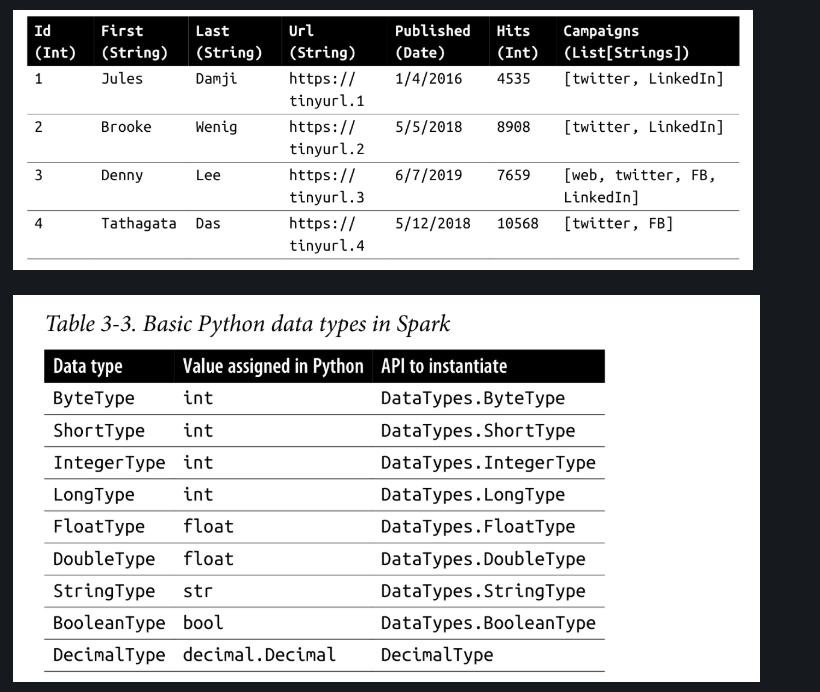

## Two ways to define a schema
Programmatically, and the other is to employ a
Data Definition Language (DDL) string, which is
much simpler and easier to read.

To define a schema programmatically for a DataFrame with three named columns,
author, title, and pages, you can use the Spark DataFrame API. For example:

In [ ]:
# 1.
from pyspark.sql.types import *
schema = StructType([StructField("author", StringType(), False),
StructField("title", StringType(), False),
StructField("pages", IntegerType(), False)])



# 2. Defining the same schema using DDL is much simpler:
schema = "author STRING, title STRING, pages INT"




In [2]:
from pyspark.sql import SparkSession
# Define schema for our data using DDL
schema = "`Id` INT, `First` STRING, `Last` STRING, `Url` STRING,`Published` STRING, `Hits` INT, `Campaigns` ARRAY<STRING>"
# Create our static data
data = [
    [1, "Jules", "Damji", "https://tinyurl.1", "1/4/2016", 4535, ["twitter", "LinkedIn"]],
    [2, "Brooke", "Wenig", "https://tinyurl.2", "5/5/2018", 8908, ["twitter", "LinkedIn"]],
    [3, "Denny", "Lee", "https://tinyurl.3", "6/7/2019", 7659, ["web", "twitter", "FB", "LinkedIn"]],
    [4, "Tathagata", "Das", "https://tinyurl.4", "5/12/2018", 10568, ["twitter", "FB"]],
    [5, "Matei", "Zaharia", "https://tinyurl.5", "5/14/2014", 40578, ["web", "twitter", "FB", "LinkedIn"]],
    [6, "Reynold", "Xin", "https://tinyurl.6", "3/2/2015", 25568, ["twitter", "LinkedIn"]]
]
# Main program
if __name__ == "__main__":
  # Create a SparkSession
  spark = (SparkSession
  .builder
  .appName("DataframeIntro")
  .getOrCreate())
  # Create a DataFrame using the schema defined above
  blogs_df = spark.createDataFrame(data, schema)
  # Show the DataFrame; it should reflect our table above
  blogs_df.show()
  # Print the schema used by Spark to process the DataFrame
  blogs_df.printSchema()

+---+---------+-------+-----------------+---------+-----+--------------------+
| Id|    First|   Last|              Url|Published| Hits|           Campaigns|
+---+---------+-------+-----------------+---------+-----+--------------------+
|  1|    Jules|  Damji|https://tinyurl.1| 1/4/2016| 4535| [twitter, LinkedIn]|
|  2|   Brooke|  Wenig|https://tinyurl.2| 5/5/2018| 8908| [twitter, LinkedIn]|
|  3|    Denny|    Lee|https://tinyurl.3| 6/7/2019| 7659|[web, twitter, FB...|
|  4|Tathagata|    Das|https://tinyurl.4|5/12/2018|10568|       [twitter, FB]|
|  5|    Matei|Zaharia|https://tinyurl.5|5/14/2014|40578|[web, twitter, FB...|
|  6|  Reynold|    Xin|https://tinyurl.6| 3/2/2015|25568| [twitter, LinkedIn]|
+---+---------+-------+-----------------+---------+-----+--------------------+

root
 |-- Id: integer (nullable = true)
 |-- First: string (nullable = true)
 |-- Last: string (nullable = true)
 |-- Url: string (nullable = true)
 |-- Published: string (nullable = true)
 |-- Hits: integer (

In [3]:
blogs_df.schema

StructType([StructField('Id', IntegerType(), True), StructField('First', StringType(), True), StructField('Last', StringType(), True), StructField('Url', StringType(), True), StructField('Published', StringType(), True), StructField('Hits', IntegerType(), True), StructField('Campaigns', ArrayType(StringType(), True), True)])

## Columns and Expressions

Named columns in DataFrames are conceptually similar to
named columns in pandas or R DataFrames or in an RDBMS table: they describe a
type of field. You can list all the columns by their names, and you can perform operations on their values using relational or computational expressions.

In [5]:
## Columns and Expressions
from pyspark.sql.functions import col, expr, concat

blogs_df.columns

['Id', 'First', 'Last', 'Url', 'Published', 'Hits', 'Campaigns']

In [6]:
# Access a particular column using col
blogs_df.select(col("Id")).show(2)

+---+
| Id|
+---+
|  1|
|  2|
+---+
only showing top 2 rows



In [7]:
# Use an expression to compute a value
blogs_df.select(expr("Hits * 2")).show(2)

+----------+
|(Hits * 2)|
+----------+
|      9070|
|     17816|
+----------+
only showing top 2 rows



In [8]:
# Or use col to compute value
blogs_df.select(col("Hits") * 2).show(2)

+----------+
|(Hits * 2)|
+----------+
|      9070|
|     17816|
+----------+
only showing top 2 rows



In [9]:
# Add a new column based on conditional expression
blogs_df.withColumn("Big Hitters", expr("Hits > 10000")).show()

+---+---------+-------+-----------------+---------+-----+--------------------+-----------+
| Id|    First|   Last|              Url|Published| Hits|           Campaigns|Big Hitters|
+---+---------+-------+-----------------+---------+-----+--------------------+-----------+
|  1|    Jules|  Damji|https://tinyurl.1| 1/4/2016| 4535| [twitter, LinkedIn]|      false|
|  2|   Brooke|  Wenig|https://tinyurl.2| 5/5/2018| 8908| [twitter, LinkedIn]|      false|
|  3|    Denny|    Lee|https://tinyurl.3| 6/7/2019| 7659|[web, twitter, FB...|      false|
|  4|Tathagata|    Das|https://tinyurl.4|5/12/2018|10568|       [twitter, FB]|       true|
|  5|    Matei|Zaharia|https://tinyurl.5|5/14/2014|40578|[web, twitter, FB...|       true|
|  6|  Reynold|    Xin|https://tinyurl.6| 3/2/2015|25568| [twitter, LinkedIn]|       true|
+---+---------+-------+-----------------+---------+-----+--------------------+-----------+



In [10]:
# Concatenate three columns into a new column
blogs_df \
    .withColumn("AuthorsId", concat(expr("First"), expr("Last"), expr("Id"))) \
    .select("AuthorsId") \
    .show(4)

+-------------+
|    AuthorsId|
+-------------+
|  JulesDamji1|
| BrookeWenig2|
|    DennyLee3|
|TathagataDas4|
+-------------+
only showing top 4 rows



In [11]:
# Concatenate three columns into a new column
blogs_df \
    .withColumn("AuthorsId", concat(col("First"), col("Last"), col("Id"))) \
    .select("AuthorsId") \
    .show(4)

+-------------+
|    AuthorsId|
+-------------+
|  JulesDamji1|
| BrookeWenig2|
|    DennyLee3|
|TathagataDas4|
+-------------+
only showing top 4 rows



In [12]:
# These statements return the same value
blogs_df.select(expr("Hits")).show(2)
blogs_df.select(col("Hits")).show(2)
blogs_df.select("Hits").show(2)

+----+
|Hits|
+----+
|4535|
|8908|
+----+
only showing top 2 rows

+----+
|Hits|
+----+
|4535|
|8908|
+----+
only showing top 2 rows

+----+
|Hits|
+----+
|4535|
|8908|
+----+
only showing top 2 rows



In [13]:
# Sort by column "Id" in descending order
blogs_df.sort(col("Id").desc()).show()

+---+---------+-------+-----------------+---------+-----+--------------------+
| Id|    First|   Last|              Url|Published| Hits|           Campaigns|
+---+---------+-------+-----------------+---------+-----+--------------------+
|  6|  Reynold|    Xin|https://tinyurl.6| 3/2/2015|25568| [twitter, LinkedIn]|
|  5|    Matei|Zaharia|https://tinyurl.5|5/14/2014|40578|[web, twitter, FB...|
|  4|Tathagata|    Das|https://tinyurl.4|5/12/2018|10568|       [twitter, FB]|
|  3|    Denny|    Lee|https://tinyurl.3| 6/7/2019| 7659|[web, twitter, FB...|
|  2|   Brooke|  Wenig|https://tinyurl.2| 5/5/2018| 8908| [twitter, LinkedIn]|
|  1|    Jules|  Damji|https://tinyurl.1| 1/4/2016| 4535| [twitter, LinkedIn]|
+---+---------+-------+-----------------+---------+-----+--------------------+



# PySpark Row Object

## Introduction to Row Objects

In PySpark, a `Row` object represents a single row of data in a DataFrame. It's a fundamental data structure that serves as an ordered collection of fields, where each field can contain different data types including primitives (integers, strings) and complex types (arrays, maps, structs).

## Key Characteristics of Row Objects

### 1. Generic Structure
- A `Row` is a generic object that can contain one or more columns
- Columns can have the same data type or different data types
- Fields are ordered and accessible by index (starting from 0)
- Fields can also be accessed by column name

### 2. Immutable Nature
- Row objects are immutable once created
- Any modifications require creating a new Row object



## Creating Row Objects

### Method 1: Using Row Constructor

In [14]:
from pyspark.sql import Row

# Create a Row with named fields
person = Row(name="John", age=30, city="New York")

# Create a Row with positional arguments
person2 = Row("Jane", 25, "Chicago")

### Method 2: From DataFrame Operations
When working with DataFrames, Row objects are automatically created:

In [15]:
# Using the provided dataset
blogs_df = spark.createDataFrame(data, schema)

# Collecting returns a list of Row objects
rows = blogs_df.collect()
print(type(rows[0]))  # <class 'pyspark.sql.types.Row'>

<class 'pyspark.sql.types.Row'>



## Accessing Row Data

### 1. Index-based Access

In [16]:
# Get the first row from our blogs DataFrame
first_row = blogs_df.first()

# Access fields by index
print(first_row[0])  # Id: 1
print(first_row[1])  # First: "Jules"
print(first_row[2])  # Last: "Damji"

1
Jules
Damji


### 2. Name-based Access

In [17]:
# Access fields by column name
print(first_row['Id'])        # 1
print(first_row['First'])     # "Jules"
print(first_row['Last'])      # "Damji"
print(first_row['Campaigns']) # ["twitter", "LinkedIn"]

# Alternative dot notation
print(first_row.Id)           # 1
print(first_row.First)        # "Jules"

1
Jules
Damji
['twitter', 'LinkedIn']
1
Jules




## Working with Complex Data Types

### Arrays in Rows

In [18]:
# Accessing array elements
first_row = blogs_df.first()
campaigns = first_row['Campaigns']
print(campaigns)           # ["twitter", "LinkedIn"]
print(campaigns[0])        # "twitter"
print(len(campaigns))      # 2

['twitter', 'LinkedIn']
twitter
2


### Example with Our Dataset

In [19]:
# Iterate through rows and access different field types
for row in blogs_df.collect():
    print(f"Author: {row['First']} {row['Last']}")
    print(f"Hits: {row['Hits']}")
    print(f"Campaigns: {', '.join(row['Campaigns'])}")
    print("---")

Author: Jules Damji
Hits: 4535
Campaigns: twitter, LinkedIn
---
Author: Brooke Wenig
Hits: 8908
Campaigns: twitter, LinkedIn
---
Author: Denny Lee
Hits: 7659
Campaigns: web, twitter, FB, LinkedIn
---
Author: Tathagata Das
Hits: 10568
Campaigns: twitter, FB
---
Author: Matei Zaharia
Hits: 40578
Campaigns: web, twitter, FB, LinkedIn
---
Author: Reynold Xin
Hits: 25568
Campaigns: twitter, LinkedIn
---




```python

```

## Common Row Operations

### 1. Converting Row to Dictionary
```python
first_row = blogs_df.first()
row_dict = first_row.asDict()
print(row_dict)
# {'Id': 1, 'First': 'Jules', 'Last': 'Damji', ...}
```

### 2. Checking Field Existence
```python
# Check if field exists
print('First' in first_row)  # True
print('Age' in first_row)    # False
```

### 3. Getting All Field Names
```python
# Get all field names
field_names = first_row.__fields__
print(field_names)  # ['Id', 'First', 'Last', 'Url', 'Published', 'Hits', 'Campaigns']
```

## Practical Examples with the Dataset

### Example 1: Filter and Process Rows
```python
# Filter rows with high hits and process
high_traffic_rows = blogs_df.filter(blogs_df.Hits > 10000).collect()

for row in high_traffic_rows:
    print(f"{row.First} {row.Last} has {row.Hits} hits")
    print(f"Published: {row.Published}")
    print(f"Campaigns: {row.Campaigns}")
```

### Example 2: Create New Rows
```python
# Create a new Row with the same structure
new_blog = Row(
    Id=7,
    First="Alice",
    Last="Johnson",
    Url="https://tinyurl.7",
    Published="1/1/2024",
    Hits=5000,
    Campaigns=["twitter", "Instagram"]
)

# Add to existing data
new_data = data + [[7, "Alice", "Johnson", "https://tinyurl.7", "1/1/2024", 5000, ["twitter", "Instagram"]]]
updated_df = spark.createDataFrame(new_data, schema)
```

### Example 3: Row Transformations
```python
# Transform rows using map operations
def process_row(row):
    return Row(
        full_name=f"{row.First} {row.Last}",
        hit_category="High" if row.Hits > 10000 else "Medium" if row.Hits > 5000 else "Low",
        campaign_count=len(row.Campaigns)
    )

# Apply transformation
processed_rdd = blogs_df.rdd.map(process_row)
processed_df = spark.createDataFrame(processed_rdd)
```

## Best Practices

### 1. Error Handling
```python
try:
    value = row['NonExistentField']
except KeyError:
    print("Field does not exist")
```

### 2. Type Safety
```python
# Check field types
first_row = blogs_df.first()
print(type(first_row.Hits))      # <class 'int'>
print(type(first_row.Campaigns)) # <class 'list'>
```

### 3. Performance Considerations
- Use `first()` instead of `collect()[0]` for getting single row
- Avoid collecting large datasets; use `take(n)` for sampling
- Consider using DataFrame operations instead of Row-level processing when possible

## Common Pitfalls

1. **Index Out of Range**: Accessing non-existent indices
2. **Field Name Errors**: Typos in field names when using string access
3. **Type Assumptions**: Assuming field types without checking
4. **Performance Issues**: Using `collect()` on large datasets

## Summary

Row objects in PySpark provide a flexible way to work with individual records in a DataFrame. They support both indexed and named access, handle complex data types, and integrate seamlessly with Spark's distributed computing model. Understanding Row objects is essential for effective data processing and transformation in PySpark applications.

---

## DataFrame operations are preferred over Row-level processing:

## Performance Reasons

### 1. **Catalyst Optimizer**
```python
# DataFrame operation - optimized by Catalyst
df.filter(df.Hits > 10000).select("First", "Last", "Hits")

# Row-level processing - NOT optimized
df.rdd.map(lambda row: (row.First, row.Last, row.Hits) if row.Hits > 10000 else None).filter(lambda x: x is not None)
```

DataFrame operations go through Spark's Catalyst optimizer, which:
- Predicate pushdown (filtering early)
- Column pruning (only read needed columns)
- Query plan optimization
- Code generation for better performance

### 2. **Serialization Overhead**
```python
# BAD: Row-level processing
def process_row(row):
    return row.Hits * 2

df.rdd.map(process_row).collect()  # Serializes each Row object
```

```python
# GOOD: DataFrame operation
df.select((df.Hits * 2).alias("double_hits"))  # No serialization overhead
```

Row objects need to be serialized/deserialized when moved between JVM and Python, which is expensive.

### 3. **Vectorized Operations**
```python
# DataFrame operations can use vectorized processing
df.select(df.Hits * 2, df.Hits + 1000)  # Vectorized

# Row-level is element-by-element
df.rdd.map(lambda row: (row.Hits * 2, row.Hits + 1000))  # One-by-one
```

## Memory Efficiency

### DataFrame Operations
- Work with columnar data structures
- Only load necessary columns
- Better memory locality

### Row-level Processing
- Materializes entire Row objects
- Higher memory footprint
- Worse cache performance

## Real Example with Your Dataset

```python
# INEFFICIENT: Row-level processing
def categorize_hits(row):
    if row.Hits > 25000:
        return "Viral"
    elif row.Hits > 10000:
        return "Popular"
    else:
        return "Normal"

# This is slow and memory-intensive
categorized_rdd = blogs_df.rdd.map(lambda row: Row(
    author=f"{row.First} {row.Last}",
    category=categorize_hits(row),
    hits=row.Hits
))
result_df = spark.createDataFrame(categorized_rdd)
```

```python
# EFFICIENT: DataFrame operations
from pyspark.sql.functions import when, col, concat, lit

result_df = blogs_df.select(
    concat(col("First"), lit(" "), col("Last")).alias("author"),
    when(col("Hits") > 25000, "Viral")
    .when(col("Hits") > 10000, "Popular")
    .otherwise("Normal").alias("category"),
    col("Hits")
)
```

## When Row-level Processing is Acceptable

Row-level processing is sometimes necessary for:

1. **Complex logic that's hard to express in DataFrame API**
2. **Integration with external Python libraries**
3. **Custom data validation**
4. **Small datasets where performance isn't critical**

```python
# Example: Complex validation logic
def validate_url(row):
    import re
    url_pattern = r'^https?://'
    return re.match(url_pattern, row.Url) is not None

# This might be acceptable for small datasets
valid_urls = blogs_df.rdd.filter(validate_url).collect()
```

## Summary

DataFrame operations are preferred because they:
- **Leverage Spark's optimization engine**
- **Reduce serialization overhead**
- **Use vectorized processing**
- **Consume less memory**
- **Scale better with large datasets**

The rule of thumb: Use DataFrame/SQL operations whenever possible, and only drop down to RDD/Row-level processing when the DataFrame API cannot express your logic efficiently.